# M1A3 - Visualização de Imagens

> **Resumo:** Primeiro contato com imagens de verdade! Aprendemos a ler imagens do disco e visualizar usando matplotlib. Aqui uso o Sonic como imagem de teste 🦔

**Estrutura do notebook:**

- Instalação e importação
- Ler imagens do disco
- Visualizar imagens
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

## Instalação e Importação da Biblioteca

In [1]:
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Ler Imagens do Disco

A função `plt.imread` lê uma imagem e retorna um **array NumPy** — é aqui que tudo se conecta com a aula anterior!

In [7]:
image = plt.imread("sonic.jpg")

Vamos verificar o tipo e espiar os valores de um pixel:

In [8]:
print(f"Tipo: {type(image)}")
print(f"Shape: {image.shape}")
print(f"Dtype: {image.dtype}")

Tipo: <class 'numpy.ndarray'>
Shape: (675, 1200, 3)
Dtype: uint8


In [9]:
# Valor RGB do pixel no canto superior esquerdo
image[0,0]

array([49, 50, 44], dtype=uint8)

## Visualizar Imagens

Com a imagem carregada em memória (como array NumPy), usamos `plt.imshow` pra visualizar:

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129428 (\N{HEDGEHOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


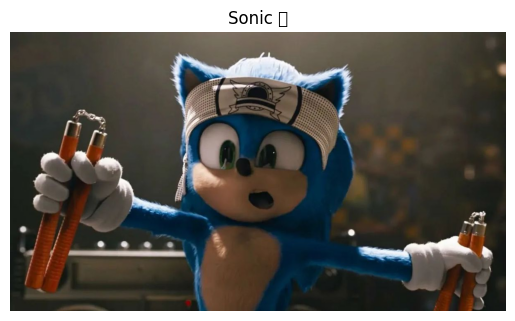

In [10]:
plt.imshow(image)
plt.title("Sonic")
plt.axis("off")
plt.show()

## Próximos Passos e Referências

Nas próximas aulas vamos explorar OpenCV, que tem muito mais ferramentas pra manipular imagens.

**Referências úteis:**

- https://matplotlib.org/stable/
- https://matplotlib.org/stable/tutorials/images.html

## ✅ Atividades Complementares

### 1. Ler outra imagem e rodar todos os comandos

Vamos usar o Tails como segunda imagem:

In [12]:
image_tails = plt.imread("tails.jpg")

print(f"Tipo: {type(image_tails)}")
print(f"Shape: {image_tails.shape}")
print(f"Dtype: {image_tails.dtype}")
print(f"Pixel [0,0]: {image_tails[0,0]}")

Tipo: <class 'numpy.ndarray'>
Shape: (1080, 1080, 3)
Dtype: uint8
Pixel [0,0]: [140 170 180]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129418 (\N{FOX FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


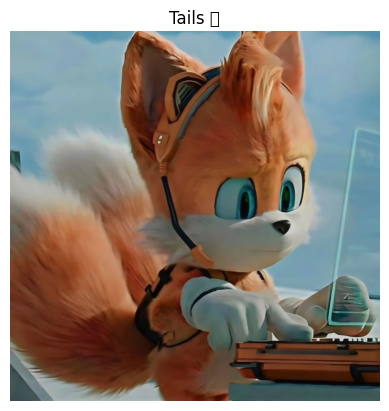

In [13]:
plt.imshow(image_tails)
plt.title("Tails")
plt.axis("off")
plt.show()

### 2. Alterar o espaço de cores

Imagens são armazenadas em RGB (Red, Green, Blue), mas podemos visualizar canais individuais ou converter pra escala de cinza:

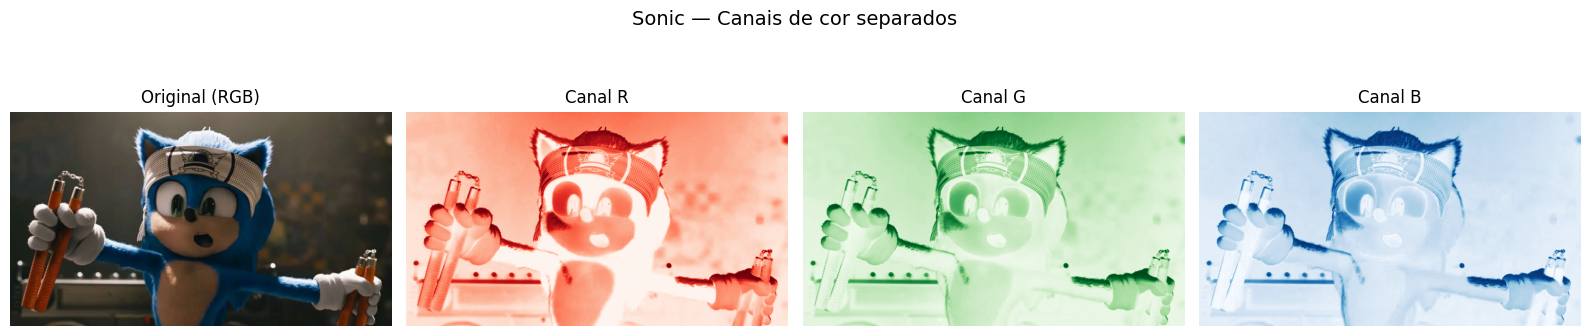

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Imagem original
axes[0].imshow(image)
axes[0].set_title("Original (RGB)")
axes[0].axis("off")

# Canal Vermelho (R)
axes[1].imshow(image[:, :, 0], cmap="Reds")
axes[1].set_title("Canal R")
axes[1].axis("off")

# Canal Verde (G)
axes[2].imshow(image[:, :, 1], cmap="Greens")
axes[2].set_title("Canal G")
axes[2].axis("off")

# Canal Azul (B)
axes[3].imshow(image[:, :, 2], cmap="Blues")
axes[3].set_title("Canal B")
axes[3].axis("off")

plt.suptitle("Sonic — Canais de cor separados", fontsize=14)
plt.tight_layout()
plt.show()

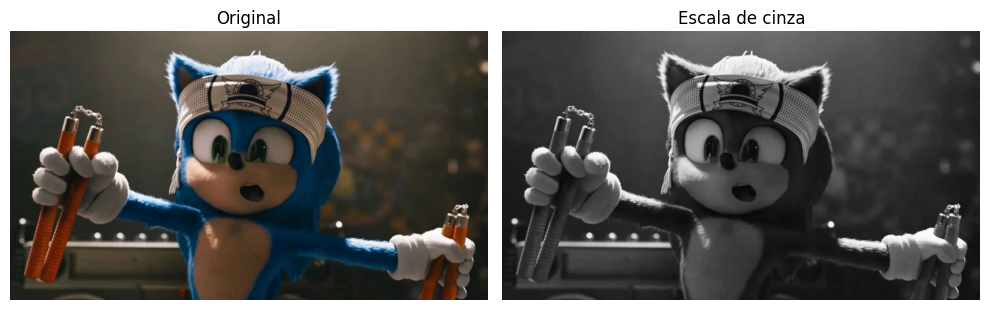

In [15]:
# Converter pra escala de cinza (média ponderada dos canais)
gray = np.dot(image[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Escala de cinza")
axes[1].axis("off")
plt.tight_layout()
plt.show()

> 📝 **Nota:** Os pesos `[0.2989, 0.5870, 0.1140]` não são arbitrários — seguem a fórmula de luminância (ITU-R BT.601) que leva em conta como o olho humano percebe cada cor. Verde tem mais peso porque somos mais sensíveis a ele!

### 3. Criar e visualizar imagens a partir de arrays NumPy

Não precisamos ler do disco — podemos criar imagens "na mão" com NumPy:

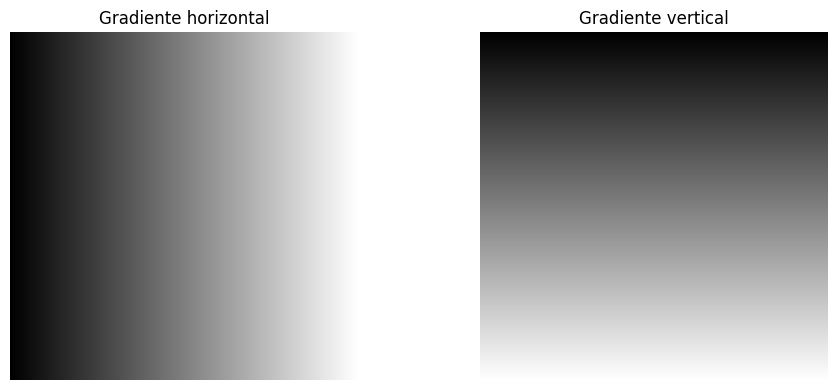

In [16]:
# Gradiente horizontal (preto → branco)
gradient_h = np.tile(np.linspace(0, 255, 256, dtype=np.uint8), (256, 1))

# Gradiente vertical (preto → branco)
gradient_v = np.tile(np.linspace(0, 255, 256, dtype=np.uint8).reshape(-1, 1), (1, 256))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gradient_h, cmap="gray")
axes[0].set_title("Gradiente horizontal")
axes[0].axis("off")
axes[1].imshow(gradient_v, cmap="gray")
axes[1].set_title("Gradiente vertical")
axes[1].axis("off")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


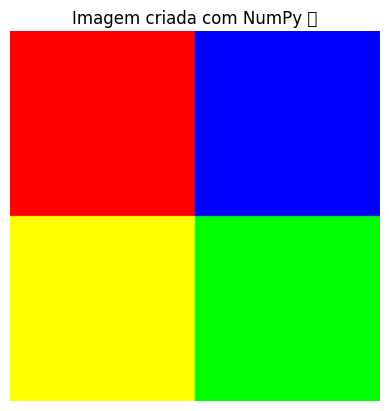

In [17]:
# Criar uma imagem RGB colorida — quadrado com 4 cores
rgb_img = np.zeros((200, 200, 3), dtype=np.uint8)
rgb_img[0:100, 0:100] = [255, 0, 0]      # Vermelho (canto superior esquerdo)
rgb_img[0:100, 100:200] = [0, 0, 255]     # Azul (canto superior direito)
rgb_img[100:200, 0:100] = [255, 255, 0]   # Amarelo (canto inferior esquerdo)
rgb_img[100:200, 100:200] = [0, 255, 0]   # Verde (canto inferior direito)

plt.imshow(rgb_img)
plt.title("Imagem criada com NumPy")
plt.axis("off")
plt.show()

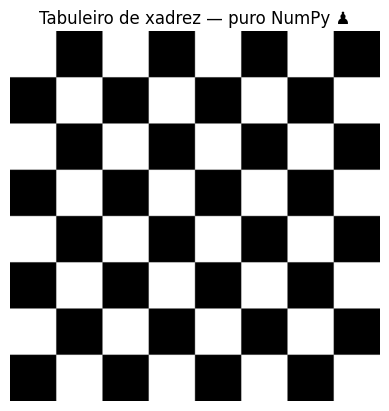

In [18]:
# Padrão xadrez
xadrez = np.zeros((200, 200), dtype=np.uint8)
tamanho_casa = 25
for i in range(0, 200, tamanho_casa):
    for j in range(0, 200, tamanho_casa):
        if (i // tamanho_casa + j // tamanho_casa) % 2 == 0:
            xadrez[i:i+tamanho_casa, j:j+tamanho_casa] = 255

plt.imshow(xadrez, cmap="gray")
plt.title("Tabuleiro de xadrez — puro NumPy")
plt.axis("off")
plt.show()

> 📝 **Conexão com visão computacional:** Criar imagens com NumPy é útil pra entender como os pixels funcionam, e também pra criar máscaras, kernels e padrões de teste mais adiante no curso.